<a href="https://colab.research.google.com/github/zuzannagr05/Projekt_PUM/blob/main/PUM_pogoda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold

In [5]:
df = pd.read_csv("/SeoulBikeData.csv", encoding="latin1")
print(df.shape)
df.info()
print(df.head())
print(df.columns)
print(df.isnull().sum())
print(df.duplicated().sum())

(8760, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Date                        8760 non-null   object 
 1   Rented Bike Count           8760 non-null   int64  
 2   Hour                        8756 non-null   float64
 3   Temperature(Â°C)            8760 non-null   float64
 4   Humidity(%)                 8760 non-null   int64  
 5   Wind speed (m/s)            8760 non-null   float64
 6   Visibility (10m)            8760 non-null   int64  
 7   Dew point temperature(Â°C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)     8760 non-null   float64
 9   Rainfall(mm)                8760 non-null   float64
 10  Snowfall (cm)               8760 non-null   float64
 11  Seasons                     8710 non-null   object 
 12  Holiday                     8760 non-null   object 
 13  Functioning Day       

Usuwanie duplikatow

In [6]:
df.drop_duplicates(inplace=True)
print(df.shape)

(8760, 14)


Zmiana nazw kolumn

In [7]:
df.columns = [
    'Date', 'Rented_Bike_Count', 'Hour', 'Temperature',
    'Humidity', 'Wind_speed', 'Visibility', 'Dew_point_temperature',
    'Solar_Radiation', 'Rainfall', 'Snowfall',
    'Seasons', 'Holiday', 'Functioning_Day'
]

print(df.columns)

Index(['Date', 'Rented_Bike_Count', 'Hour', 'Temperature', 'Humidity',
       'Wind_speed', 'Visibility', 'Dew_point_temperature', 'Solar_Radiation',
       'Rainfall', 'Snowfall', 'Seasons', 'Holiday', 'Functioning_Day'],
      dtype='object')


konwersja daty

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [9]:
# usunięcie oryginalnej daty
df.drop(columns=['Date'], inplace=True)

In [10]:
#uzupełnienie braków danych
df['Hour'] = df['Hour'].fillna(df['Hour'].median())
df['Seasons'] = df['Seasons'].fillna(df['Seasons'].mode()[0])

print("Braki po uzupełnieniu:\n", df.isnull().sum())

Braki po uzupełnieniu:
 Rented_Bike_Count        0
Hour                     0
Temperature              0
Humidity                 0
Wind_speed               0
Visibility               0
Dew_point_temperature    0
Solar_Radiation          0
Rainfall                 0
Snowfall                 0
Seasons                  0
Holiday                  0
Functioning_Day          0
Year                     0
Month                    0
Day                      0
DayOfWeek                0
dtype: int64


In [11]:
# kodowanie zmiennych tekstowych
le = LabelEncoder()

for col in ['Seasons', 'Holiday', 'Functioning_Day']:
    df[col] = le.fit_transform(df[col])

print(df.head())
print(df.dtypes)

   Rented_Bike_Count  Hour  Temperature  Humidity  Wind_speed  Visibility  \
0                254   0.0         -5.2        37         2.2        2000   
1                204   1.0         -5.5        38         0.8        2000   
2                173   2.0         -6.0        39         1.0        2000   
3                107   3.0         -6.2        40         0.9        2000   
4                 78   4.0         -6.0        36         2.3        2000   

   Dew_point_temperature  Solar_Radiation  Rainfall  Snowfall  Seasons  \
0                  -17.6              0.0       0.0       0.0        3   
1                  -17.6              0.0       0.0       0.0        3   
2                  -17.7              0.0       0.0       0.0        3   
3                  -17.6              0.0       0.0       0.0        3   
4                  -18.6              0.0       0.0       0.0        3   

   Holiday  Functioning_Day  Year  Month  Day  DayOfWeek  
0        1                1  2017

In [12]:
print(df.describe())

       Rented_Bike_Count         Hour  Temperature     Humidity  \
count        8760.000000  8760.000000  8760.000000  8760.000000   
mean          704.602055    11.498402    12.882922    58.226256   
std           644.997468     6.921872    11.944825    20.362413   
min             0.000000     0.000000   -17.800000     0.000000   
25%           191.000000     5.750000     3.500000    42.000000   
50%           504.500000    11.000000    13.700000    57.000000   
75%          1065.250000    17.000000    22.500000    74.000000   
max          3556.000000    23.000000    39.400000    98.000000   

          Wind_speed   Visibility  Dew_point_temperature  Solar_Radiation  \
count    8760.000000  8760.000000            8760.000000      8760.000000   
mean       70.215799  1436.825799               4.073813         0.569111   
std      6410.589324   608.298712              13.060369         0.868746   
min        -3.000000    27.000000             -30.600000         0.000000   
25%        

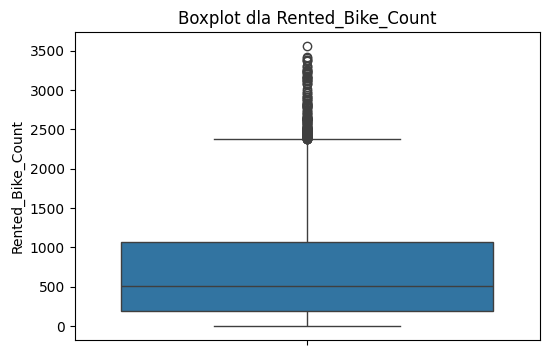

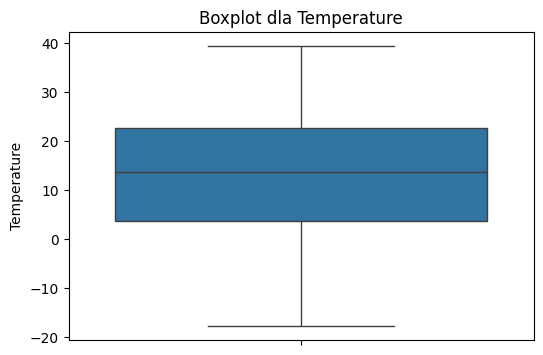

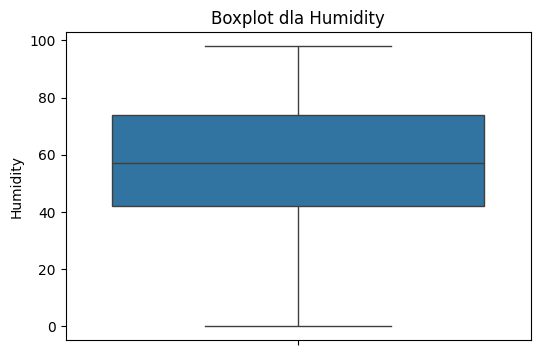

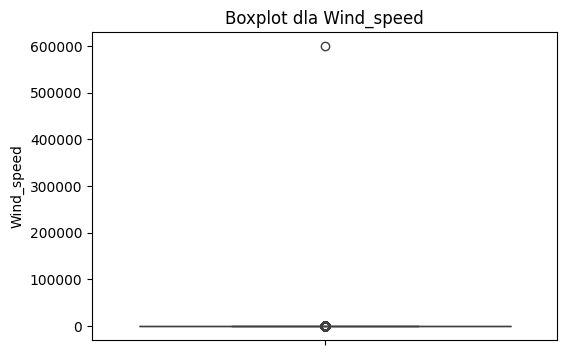

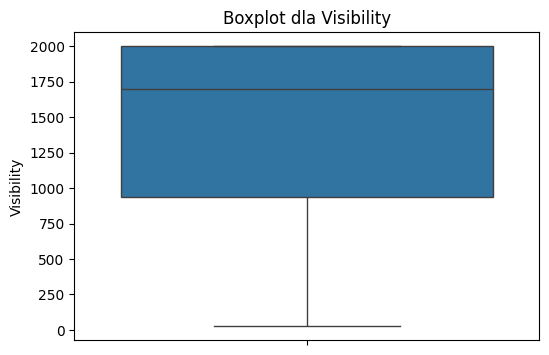

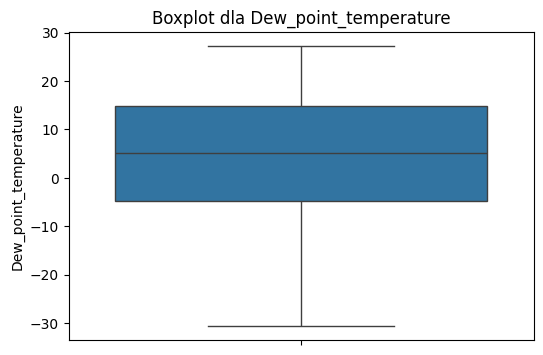

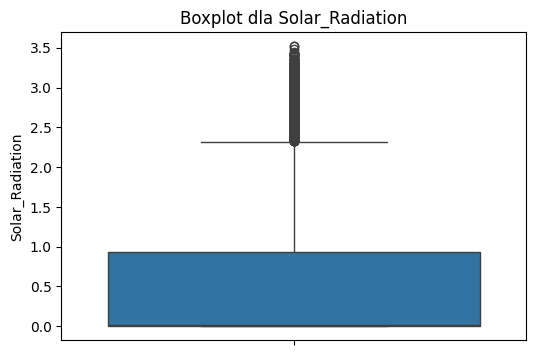

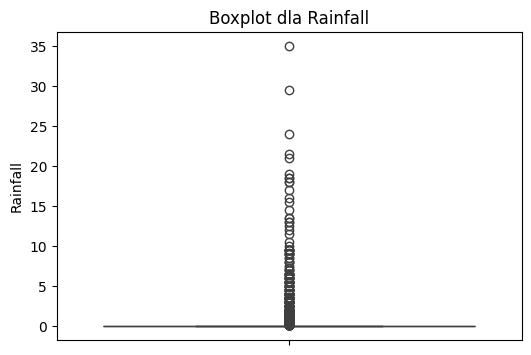

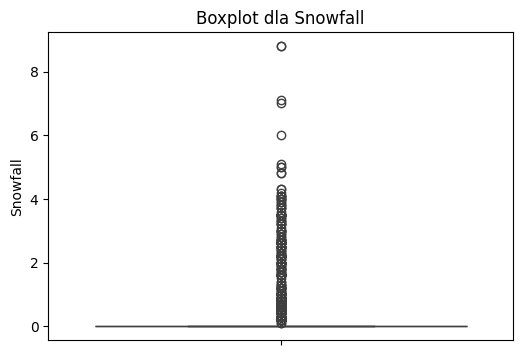

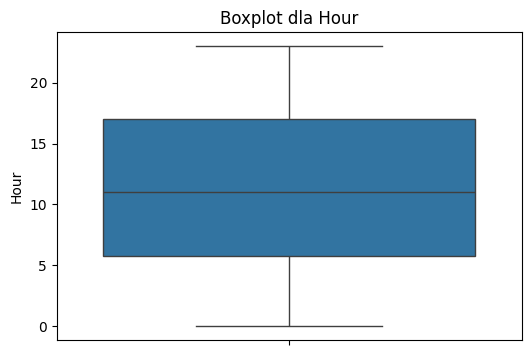

In [13]:
# wykresy dla wybranych zmiennych
num_cols = ['Rented_Bike_Count', 'Temperature', 'Humidity', 'Wind_speed',
            'Visibility', 'Dew_point_temperature', 'Solar_Radiation',
            'Rainfall', 'Snowfall', 'Hour']

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot dla {col}')
    plt.show()


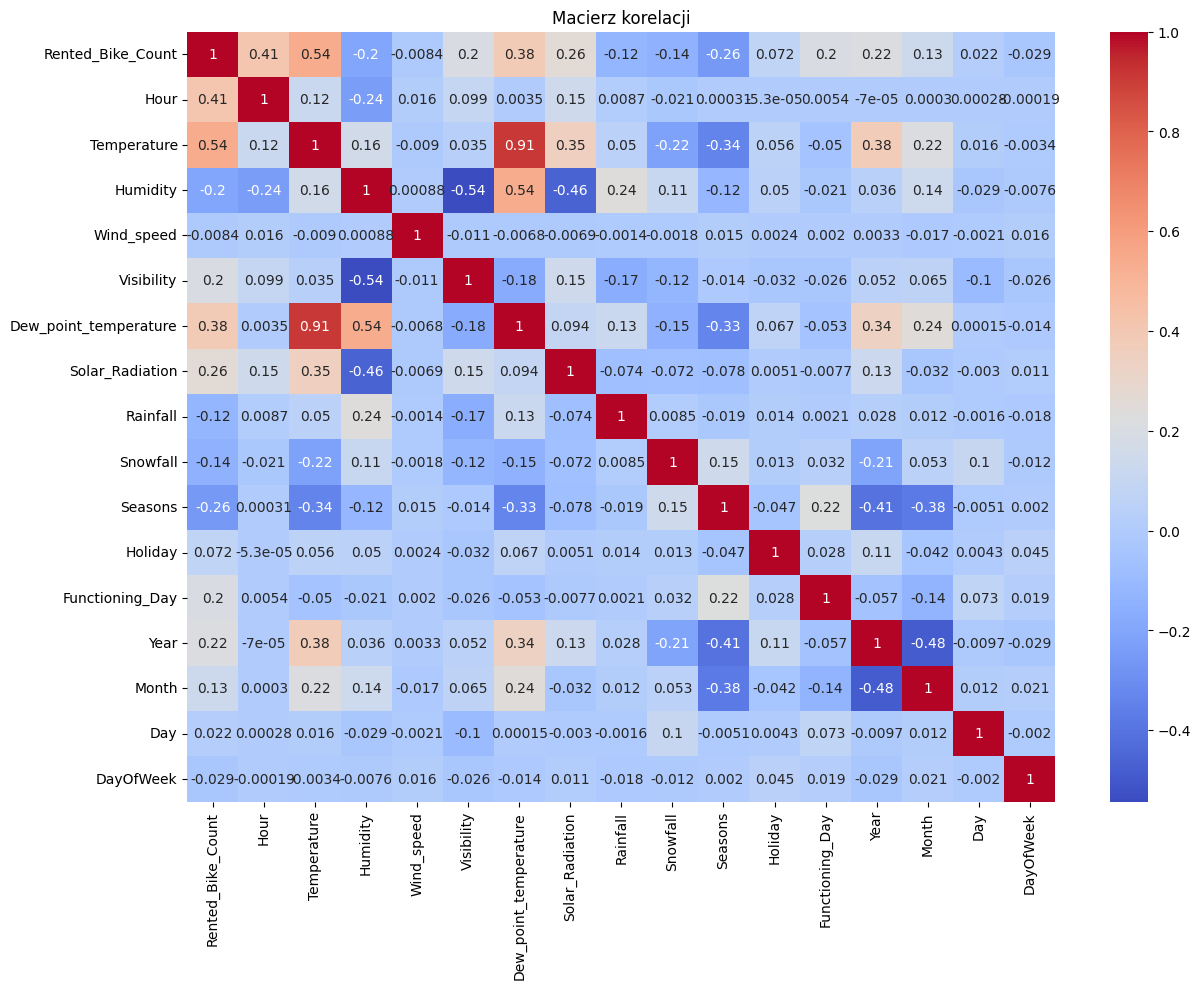

In [14]:
# macierz koleracji
corr_matrix = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Macierz korelacji")
plt.show()

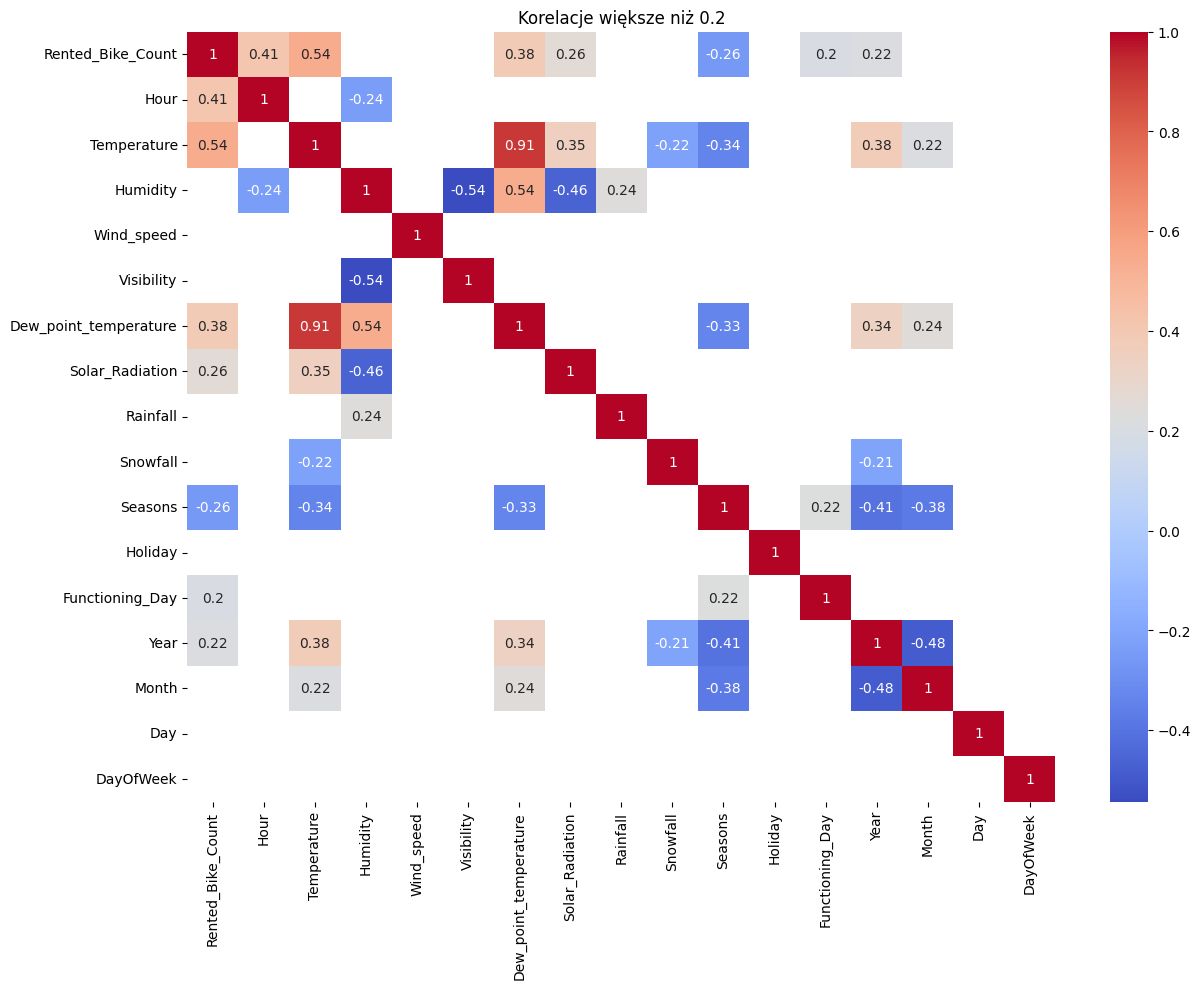

In [15]:
# korelacje powyżej 0.2
high_corr = corr_matrix[abs(corr_matrix) > 0.2]

plt.figure(figsize=(14, 10))
sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plt.title("Korelacje większe niż 0.2")
plt.show()